#  Introduction to Machine Learning & Scikit-learn
## Building Your First ML Pipeline

---
**Welcome!** In this notebook, we will go through everything step by step — from understanding what Machine Learning is, all the way to building a complete ML pipeline that predicts house prices.

We will use the **California Housing Dataset** — a real dataset that is already built into scikit-learn. No need to download anything!

### What We Will Cover:
1. What is Machine Learning?
2. Loading and Exploring the Dataset
3. Train-Test Split
4. Feature Scaling
5. Handling Missing Values
6. Encoding Categorical Variables
7. Cross-Validation (K-Fold & Stratified K-Fold)
8. Building ML Pipelines
9. Evaluating the Model (MAE, MSE, RMSE, R²)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# The dataset we will use (built into scikit-learn!)
from sklearn.datasets import fetch_california_housing
# For splitting data
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
# For scaling (normalising) features
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# For encoding categorical variables
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
# For handling missing values
from sklearn.impute import SimpleImputer
# For building pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# The ML model we will use — Linear Regression
from sklearn.linear_model import LinearRegression

# For evaluating our model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Set random seed so results are reproducible (same every time)
np.random.seed(42)

The **California Housing Dataset** contains information about housing blocks in California, USA.

Each row represents a **neighbourhood block**, and the goal is to predict the **median house value** (the target variable — what we want to predict).

### Features in the Dataset:
| Feature | Description |
|---|---|
| MedInc | Median income in the block |
| HouseAge | Median age of the houses |
| AveRooms | Average number of rooms per house |
| AveBedrms | Average number of bedrooms per house |
| Population | Block population |
| AveOccup | Average household size |
| Latitude | Latitude of the block |
| Longitude | Longitude of the block |
| **MedHouseVal** |  TARGET: Median House Value (in $100,000s) |

In [43]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
#adding the target variable
df['MedHouseVal'] = housing.target

In [44]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [45]:
print(f" Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTarget variable: MedHouseVal (Median House Value in $100,000s)")

 Dataset shape: 20640 rows × 9 columns

Target variable: MedHouseVal (Median House Value in $100,000s)


In [46]:
print("First 5 rows of the dataset:")
print("(Each row = one neighbourhood block in California)\n")
df.head()

First 5 rows of the dataset:
(Each row = one neighbourhood block in California)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [48]:
print(f"Number of rows    : {df.shape[0]:,}  (each row = one housing block)")
print(f" Number of columns : {df.shape[1]}  (8 features + 1 target)")
print()
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    tag = " ← TARGET (what we want to predict!)" if col == 'MedHouseVal' else ""
    print(f"   {i:2}. {col}{tag}")

Number of rows    : 20,640  (each row = one housing block)
 Number of columns : 9  (8 features + 1 target)

Column Names:
    1. MedInc
    2. HouseAge
    3. AveRooms
    4. AveBedrms
    5. Population
    6. AveOccup
    7. Latitude
    8. Longitude
    9. MedHouseVal ← TARGET (what we want to predict!)



## Dataset Summary (.info)

`.info()` shows us:
- The **data type** of each column (float, int, object, etc.)
- How many **non-null** (non-missing) values each column has
- The overall **memory usage** of the dataset

This helps us spot missing values and understand our data types.

In [50]:
# DATASET INFO

print(" Dataset Info:")
df.info()

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Statistical Summary (.describe)

`.describe()` gives us key **statistics** for every column:
- **count** — number of values
- **mean** — average value
- **std** — standard deviation (how spread out the values are)
- **min / max** — smallest and largest values
- **25%, 50%, 75%** — quartiles (splits data into 4 equal parts)

In [54]:
# STATISTICAL SUMMARY

print("Statistical Summary of All Columns:")
df.describe().round(2)

Statistical Summary of All Columns:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


##  Check for Missing Values

In [55]:
missing = df.isnull().sum()

print("Missing Values per Column:")
print(missing)
print()

Missing Values per Column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64



## Visualise the Target Variable

Let's look at the distribution of **MedHouseVal** — the variable we want to predict.

This tells us:
- What range are house prices in?
- Are most houses cheap or expensive?
- Is the data skewed (one-sided)?

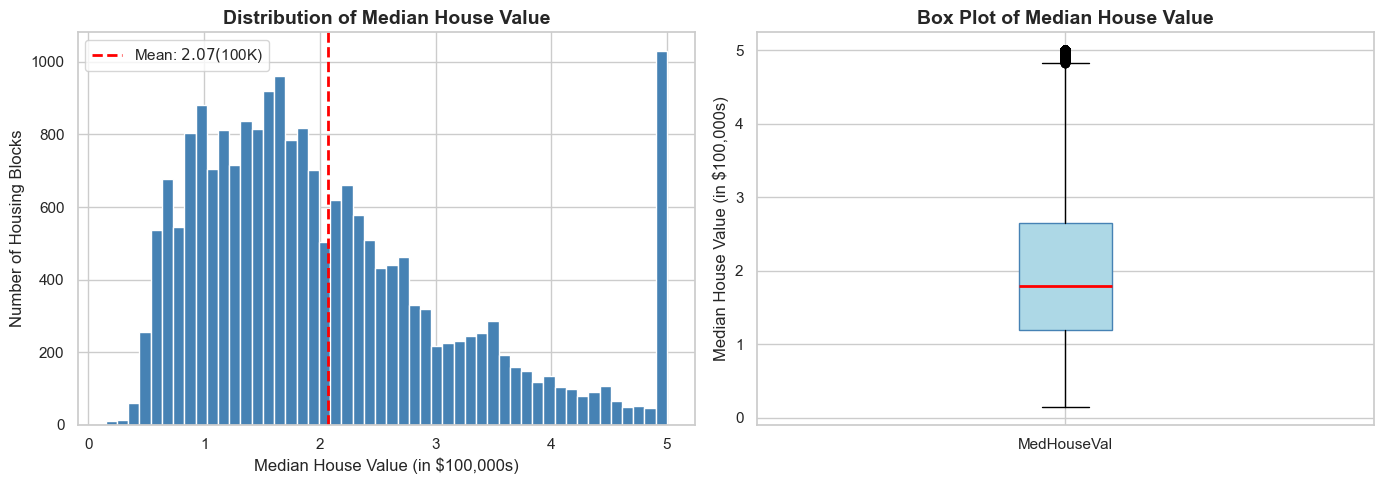


 Target Variable Summary:
   Minimum  : $0.15 ($100K) = $14,999
   Maximum  : $5.00 ($100K) = $500,001
   Average  : $2.07 ($100K) = $206,856

   Notice the cap at 5.0 ($500,000) — very expensive homes were capped in the original data.


In [56]:
# VISUALISE THE TARGET VARIABLE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Histogram ---
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Median House Value (in $100,000s)')
axes[0].set_ylabel('Number of Housing Blocks')
axes[0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["MedHouseVal"].mean():.2f} ($100K)')
axes[0].legend()

# --- Chart 2: Box Plot ---
axes[1].boxplot(df['MedHouseVal'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot of Median House Value', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Median House Value (in $100,000s)')
axes[1].set_xticklabels(['MedHouseVal'])

plt.tight_layout()
plt.show()

print(f"\n Target Variable Summary:")
print(f"   Minimum  : ${df['MedHouseVal'].min():.2f} ($100K) = ${df['MedHouseVal'].min()*100000:,.0f}")
print(f"   Maximum  : ${df['MedHouseVal'].max():.2f} ($100K) = ${df['MedHouseVal'].max()*100000:,.0f}")
print(f"   Average  : ${df['MedHouseVal'].mean():.2f} ($100K) = ${df['MedHouseVal'].mean()*100000:,.0f}")
print(f"\n   Notice the cap at 5.0 ($500,000) — very expensive homes were capped in the original data.")

##  Visualise All Features (Histograms)

checking the distribution of **all features** at once.

This helps us understand:
- Are features normally distributed or skewed?
- Are there any extreme outliers?
- Do features have very different ranges? (This is why we need **scaling**!)

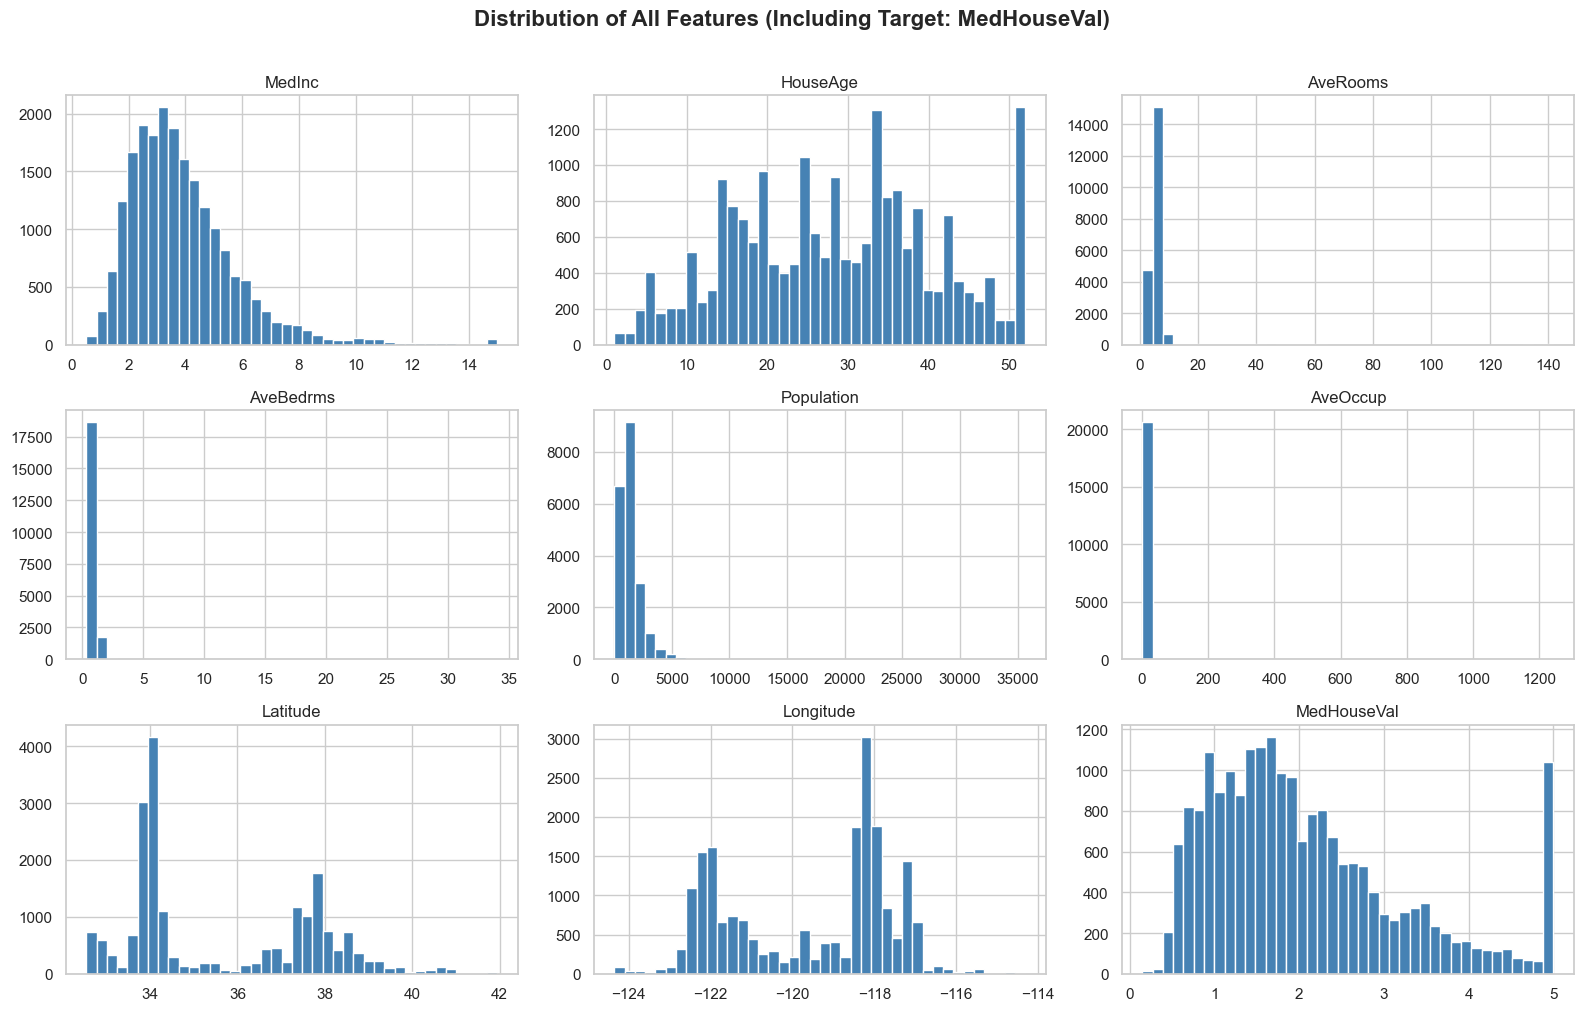


 What do you notice?
   - MedInc (income) seems to have some high outliers
   - Latitude and Longitude are grouped around California's location
   - MedHouseVal (our target) is skewed right — most houses are cheaper
   - Features have VERY different ranges (e.g., Population vs HouseAge)
   → This is exactly WHY we need Feature Scaling! (We'll do this soon)


In [57]:
# VISUALISE ALL FEATURES

df.hist(bins=40, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of All Features (Including Target: MedHouseVal)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n What do you notice?")
print("   - MedInc (income) seems to have some high outliers")
print("   - Latitude and Longitude are grouped around California's location")
print("   - MedHouseVal (our target) is skewed right — most houses are cheaper")
print("   - Features have VERY different ranges (e.g., Population vs HouseAge)")
print("   → This is exactly WHY we need Feature Scaling! (We'll do this soon)")

## Correlation Heatmap

A **correlation** tells us how strongly two variables are related.

- **+1.0** = Perfect positive relationship (as one goes up, the other goes up)
- **-1.0** = Perfect negative relationship (as one goes up, the other goes down)
- **0.0** = No relationship


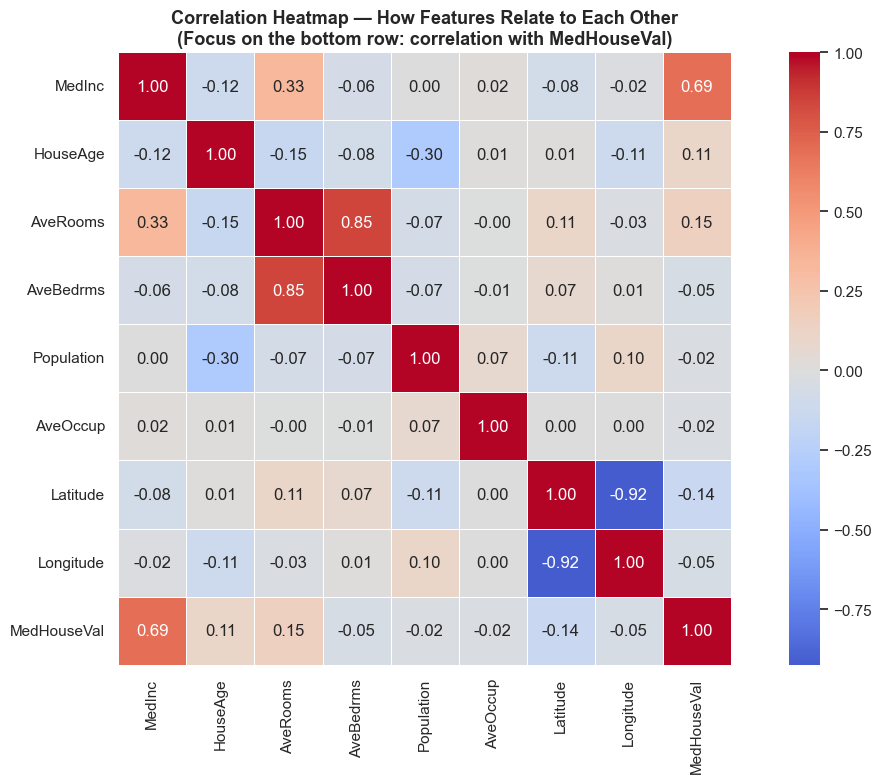


Correlation of Each Feature WITH the Target (MedHouseVal):
   (Higher absolute value = stronger relationship with house price)

   MedInc          +0.688                       ↑ Positive
   AveRooms        +0.152                       ↑ Positive
   HouseAge        +0.106                       ↑ Positive
   AveOccup        -0.024                       ↓ Negative
   Population      -0.025                       ↓ Negative
   Longitude       -0.046                       ↓ Negative
   AveBedrms       -0.047                       ↓ Negative
   Latitude        -0.144                       ↓ Negative


In [59]:
# CORRELATION HEATMAP

plt.figure(figsize=(12, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix,
            annot=True,          # Show the numbers inside each box
            fmt='.2f',           # Round to 2 decimal places
            cmap='coolwarm',     # Color: blue = negative, red = positive
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap — How Features Relate to Each Other\n(Focus on the bottom row: correlation with MedHouseVal)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlation with target specifically
print("\nCorrelation of Each Feature WITH the Target (MedHouseVal):")
print("   (Higher absolute value = stronger relationship with house price)\n")
target_corr = corr_matrix['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
for feat, val in target_corr.items():
    bar = '' * int(abs(val) * 20)
    direction = '↑ Positive' if val > 0 else '↓ Negative'
    print(f"   {feat:<15} {val:+.3f}  {bar:<20} {direction}")

## Train-Test Split

In [61]:
# SEPARATE FEATURES (X) AND TARGET (y)

# X = all columns EXCEPT the target (these are our input features)
X = df.drop('MedHouseVal', axis=1)
# y = the target column only (this is what we want to predict)
y = df['MedHouseVal']


In [62]:
print(f"Features (X): {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"Target  (y): {y.shape[0]:,} values")
print(f"\n   Feature columns: {list(X.columns)}")

Features (X): 20,640 rows × 8 columns
Target  (y): 20,640 values

   Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [63]:
# PERFORM THE TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,               # Features
    y,               # Target
    test_size=0.2,   # 20% goes to test set, 80% goes to training set
    random_state=42  # Set a seed so we get the same split every time we run this
)

print(" Data split complete!")
print()
print(f"Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}% of data) — MODEL LEARNS FROM THIS")
print(f" Test set     : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}% of data) — MODEL IS TESTED ON THIS")
print()

 Data split complete!

Training set : 16,512 rows (80% of data) — MODEL LEARNS FROM THIS
 Test set     : 4,128 rows  (20% of data) — MODEL IS TESTED ON THIS



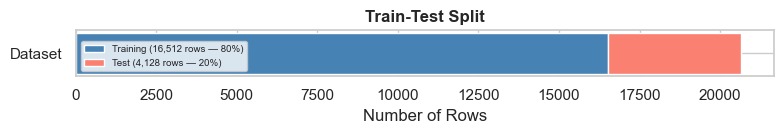

In [70]:
# Visualise the split
fig, ax = plt.subplots(figsize=(8, 1.5))
ax.barh(['Dataset'], [X_train.shape[0]], color='steelblue', label=f'Training ({X_train.shape[0]:,} rows — 80%)')
ax.barh(['Dataset'], [X_test.shape[0]], left=[X_train.shape[0]], color='salmon', label=f'Test ({X_test.shape[0]:,} rows — 20%)')
ax.set_xlabel('Number of Rows')
ax.set_title('Train-Test Split', fontweight='bold')
ax.legend(loc='lower left', fontsize=7)
plt.tight_layout()
plt.show()


##  Feature Scaling

Look at the ranges of our features:
- **Population** can be in the thousands
- **HouseAge** is between 1 and 52
- **Latitude/Longitude** are between 32 and 42


### Three Types of Scalers:
| Scaler | How it works | Best for |
|---|---|---|
| **StandardScaler** | Mean = 0, Std = 1 | Most situations |
| **MinMaxScaler** | Scales to [0, 1] range | When you need bounded output |
| **RobustScaler** | Uses median & IQR | When data has many outliers |

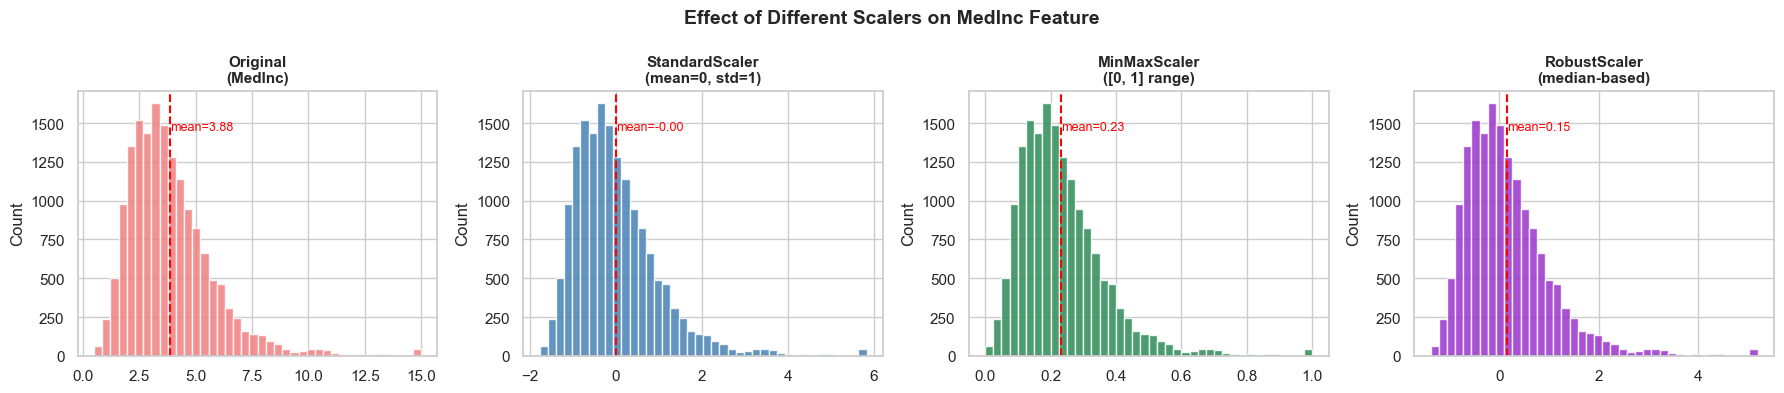

 Key Insight:
   The SHAPE of the distribution stays the same — scaling only changes the RANGE!
   StandardScaler is the most commonly used scaler in practice.


In [71]:
# COMPARE THE THREE SCALERS

# We'll use 'MedInc' (Median Income) as our example feature
sample_feature = X_train[['MedInc']].copy()

# Apply each scaler
standard_scaled = StandardScaler().fit_transform(sample_feature)
minmax_scaled   = MinMaxScaler().fit_transform(sample_feature)
robust_scaled   = RobustScaler().fit_transform(sample_feature)

# Plot all four (original + 3 scaled versions)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

data_to_plot = [
    (sample_feature.values, 'Original\n(MedInc)', 'lightcoral'),
    (standard_scaled, 'StandardScaler\n(mean=0, std=1)', 'steelblue'),
    (minmax_scaled, 'MinMaxScaler\n([0, 1] range)', 'seagreen'),
    (robust_scaled, 'RobustScaler\n(median-based)', 'darkorchid'),
]

for ax, (data, title, color) in zip(axes, data_to_plot):
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Count')
    mean_val = data.mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5)
    ax.annotate(f'mean={mean_val:.2f}', xy=(mean_val, ax.get_ylim()[1]*0.85),
                color='red', fontsize=9, ha='left')

plt.suptitle('Effect of Different Scalers on MedInc Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Key Insight:")
print("   The SHAPE of the distribution stays the same — scaling only changes the RANGE!")
print("   StandardScaler is the most commonly used scaler in practice.")

In [72]:
# APPLY STANDARDSCALER TO OUR ACTUAL DATA

# IMPORTANT RULE:
# - fit() on TRAINING data only (so the scaler learns from training data)
# - transform() on BOTH training and test data
# - NEVER fit() on test data — that would be cheating (data leakage!)

scaler = StandardScaler()

# Fit on training data AND transform training data
X_train_scaled = scaler.fit_transform(X_train)

# ONLY transform test data (no fitting!)
X_test_scaled  = scaler.transform(X_test)

# Compare before and after for one column
col_idx = 0  # MedInc column
print("Scaling complete!")
print()
print(f"MedInc BEFORE scaling: mean = {X_train['MedInc'].mean():.3f}, std = {X_train['MedInc'].std():.3f}")
print(f"MedInc AFTER  scaling: mean = {X_train_scaled[:, col_idx].mean():.3f}, std = {X_train_scaled[:, col_idx].std():.3f}")
print()
print(" IMPORTANT RULE:")
print("   fit_transform() on TRAINING data → scaler learns the mean and std from training data")
print("   transform() only on TEST data    → applies the SAME transformation (no peeking at test!)")

Scaling complete!

MedInc BEFORE scaling: mean = 3.881, std = 1.904
MedInc AFTER  scaling: mean = -0.000, std = 1.000

 IMPORTANT RULE:
   fit_transform() on TRAINING data → scaler learns the mean and std from training data
   transform() only on TEST data    → applies the SAME transformation (no peeking at test!)


## Encoding Categorical Variables (Demo)

**Two main methods:**
- **OneHotEncoder** → For nominal (no order) categories
- **LabelEncoder** → For ordinal (has order) categories

In [73]:
# ENCODING CATEGORICAL VARIABLES — DEMO WITH EXAMPLE DATA

# creating a small dataset to demonstrate encoding
example_df = pd.DataFrame({
    'City':      ['Lagos', 'Abuja', 'Kano', 'Lagos', 'Abuja', 'Port Harcourt'],
    'Condition': ['Good',  'Fair',  'Poor', 'Fair',  'Good',  'Poor'],
    'Price':     [250,      180,     120,    200,     190,     110]
})

print(" Example Dataset (before encoding):")
print(example_df)
print()
print("Problem: ML models can't understand 'Lagos' or 'Good' — they need NUMBERS!")

 Example Dataset (before encoding):
            City Condition  Price
0          Lagos      Good    250
1          Abuja      Fair    180
2           Kano      Poor    120
3          Lagos      Fair    200
4          Abuja      Good    190
5  Port Harcourt      Poor    110

Problem: ML models can't understand 'Lagos' or 'Good' — they need NUMBERS!


In [74]:
# ONE-HOT ENCODING — For Nominal (Unordered) Categories
# Use when: there is NO meaningful order (City names, colours, etc.)


# OneHotEncoder creates a new binary column for each unique category
# Example: City → City_Lagos | City_Abuja | City_Kano | City_Port Harcourt

ohe = OneHotEncoder(sparse_output=False)  # sparse_output=False → gives us a normal array
city_encoded = ohe.fit_transform(example_df[['City']])

# Convert to DataFrame so it looks nice
city_df = pd.DataFrame(city_encoded, columns=ohe.get_feature_names_out(['City']))

print(" OneHotEncoder — City Column (Nominal = No Order):")
print("Each city gets its OWN column. 1 = yes, 0 = no.\n")
print(pd.concat([example_df[['City']], city_df], axis=1).to_string(index=False))
print()
print("Why OneHot? Because Lagos ≠ Abuja + Kano. There's no order between cities.")

 OneHotEncoder — City Column (Nominal = No Order):
Each city gets its OWN column. 1 = yes, 0 = no.

         City  City_Abuja  City_Kano  City_Lagos  City_Port Harcourt
        Lagos         0.0        0.0         1.0                 0.0
        Abuja         1.0        0.0         0.0                 0.0
         Kano         0.0        1.0         0.0                 0.0
        Lagos         0.0        0.0         1.0                 0.0
        Abuja         1.0        0.0         0.0                 0.0
Port Harcourt         0.0        0.0         0.0                 1.0

Why OneHot? Because Lagos ≠ Abuja + Kano. There's no order between cities.


In [75]:
# LABEL ENCODING — For Ordinal (Ordered) Categories
# Use when: there IS a meaningful order (Poor < Fair < Good)

# LabelEncoder converts categories to integers: Poor→0, Fair→1, Good→2

# We manually define the order (alphabetically is not always correct!)
condition_order = {'Poor': 0, 'Fair': 1, 'Good': 2}
example_df['Condition_Encoded'] = example_df['Condition'].map(condition_order)

print("Label Encoding — Condition Column (Ordinal = Has Order):")
print("   Poor=0, Fair=1, Good=2 (preserves the order!)\n")
print(example_df[['Condition', 'Condition_Encoded']].drop_duplicates().sort_values('Condition_Encoded').to_string(index=False))
print()
print("Why Label? Because Poor < Fair < Good. There IS a meaningful order.")
print("   Using OneHot here would lose the ordering information.")

Label Encoding — Condition Column (Ordinal = Has Order):
   Poor=0, Fair=1, Good=2 (preserves the order!)

Condition  Condition_Encoded
     Poor                  0
     Fair                  1
     Good                  2

Why Label? Because Poor < Fair < Good. There IS a meaningful order.
   Using OneHot here would lose the ordering information.


## Handling Missing Values (Demo)

In real datasets, you'll almost always have missing values (empty cells).

**Three strategies:**
1. **Drop** — Remove rows or columns with missing values
2. **Impute (fill)** — Fill with mean, median, or mode
3. **Predict** — Use a model to predict the missing value (advanced)

We'll use **SimpleImputer** from scikit-learn.

In [76]:
# HANDLING MISSING VALUES — DEMO

# Create a sample dataset WITH missing values
np.random.seed(42)
missing_demo = pd.DataFrame({
    'Rooms':      [4, 3, np.nan, 5, 2, np.nan, 3, 4, np.nan, 5],
    'Age':        [10, np.nan, 25, 15, np.nan, 30, 20, np.nan, 18, 12],
    'Price':      [200, 180, 150, np.nan, 120, 160, 175, 190, np.nan, 220]
})

print("Dataset WITH Missing Values (NaN = missing):")
print(missing_demo)
print(f"\n Total missing values: {missing_demo.isnull().sum().sum()}")
print(missing_demo.isnull().sum())

Dataset WITH Missing Values (NaN = missing):
   Rooms   Age  Price
0    4.0  10.0  200.0
1    3.0   NaN  180.0
2    NaN  25.0  150.0
3    5.0  15.0    NaN
4    2.0   NaN  120.0
5    NaN  30.0  160.0
6    3.0  20.0  175.0
7    4.0   NaN  190.0
8    NaN  18.0    NaN
9    5.0  12.0  220.0

 Total missing values: 8
Rooms    3
Age      3
Price    2
dtype: int64


In [77]:
# STRATEGY 1: Drop rows with missing values

dropped = missing_demo.dropna()
print("Strategy 1 — Drop rows with missing values:")
print(f"Before: {len(missing_demo)} rows | After: {len(dropped)} rows")
print("Warning: We lost a lot of data! Only use this if you have PLENTY of data.\n")


Strategy 1 — Drop rows with missing values:
Before: 10 rows | After: 3 rows



In [78]:
# STRATEGY 2: Impute with Mean

imputer_mean = SimpleImputer(strategy='mean')  # Replace NaN with column mean
filled_mean  = pd.DataFrame(imputer_mean.fit_transform(missing_demo), columns=missing_demo.columns)

print("Strategy 2 — Fill with Mean (most common strategy):")
print(filled_mean.round(1))
print(f"\n No more missing values! All NaN values replaced with column means.")

Strategy 2 — Fill with Mean (most common strategy):
   Rooms   Age  Price
0    4.0  10.0  200.0
1    3.0  18.6  180.0
2    3.7  25.0  150.0
3    5.0  15.0  174.4
4    2.0  18.6  120.0
5    3.7  30.0  160.0
6    3.0  20.0  175.0
7    4.0  18.6  190.0
8    3.7  18.0  174.4
9    5.0  12.0  220.0

 No more missing values! All NaN values replaced with column means.


In [79]:
# COMPARE STRATEGIES VISUALLY

imputer_median = SimpleImputer(strategy='median')
imputer_mode   = SimpleImputer(strategy='most_frequent')

filled_median = pd.DataFrame(imputer_median.fit_transform(missing_demo), columns=missing_demo.columns)
filled_mode   = pd.DataFrame(imputer_mode.fit_transform(missing_demo), columns=missing_demo.columns)

print(" Comparison of Imputation Strategies for 'Rooms' column:")
print(f"   Original values (with NaN): {list(missing_demo['Rooms'])}")
print(f"   Mean imputed:               {list(filled_mean['Rooms'].round(1))}")
print(f"   Median imputed:             {list(filled_median['Rooms'].round(1))}")
print(f"   Mode imputed:               {list(filled_mode['Rooms'].round(1))}")
print()
print(" Which to use?")
print("   Mean   → Good default, but sensitive to outliers")
print("   Median → Better when data has outliers")
print("   Mode   → Best for categorical or discrete features")

 Comparison of Imputation Strategies for 'Rooms' column:
   Original values (with NaN): [4.0, 3.0, nan, 5.0, 2.0, nan, 3.0, 4.0, nan, 5.0]
   Mean imputed:               [4.0, 3.0, 3.7, 5.0, 2.0, 3.7, 3.0, 4.0, 3.7, 5.0]
   Median imputed:             [4.0, 3.0, 4.0, 5.0, 2.0, 4.0, 3.0, 4.0, 4.0, 5.0]
   Mode imputed:               [4.0, 3.0, 3.0, 5.0, 2.0, 3.0, 3.0, 4.0, 3.0, 5.0]

 Which to use?
   Mean   → Good default, but sensitive to outliers
   Median → Better when data has outliers
   Mode   → Best for categorical or discrete features



## Cross-Validation

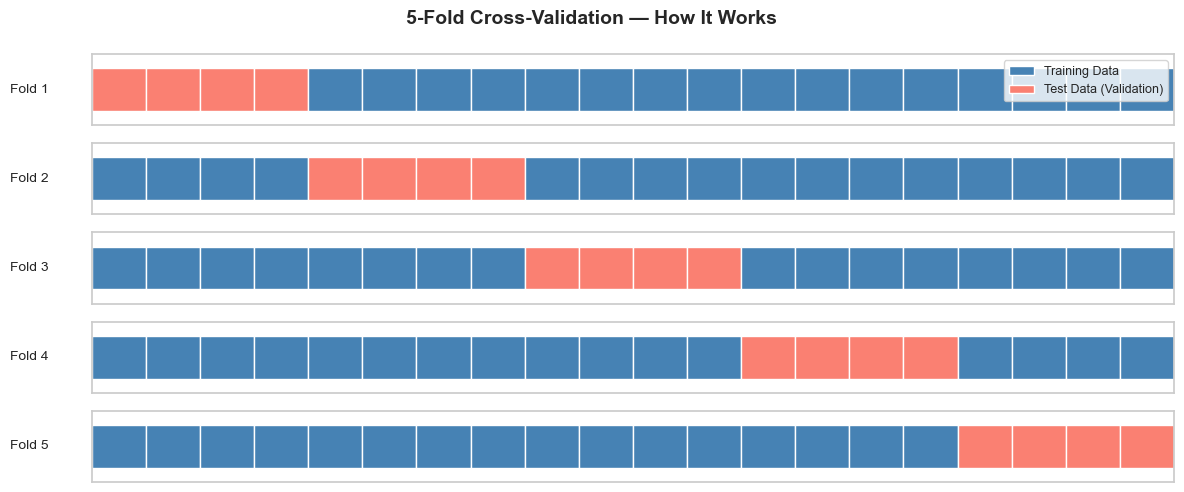


 In each fold:
   - The RED portion is used as the TEST set
   - The BLUE portion is used as the TRAINING set
   - The model is trained and evaluated 5 times, once per fold
   - Final score = average of all 5 scores


In [80]:
# K-FOLD CROSS-VALIDATION VISUALISATION

k = 5  # Number of folds
n = 20  # Simplified: imagine we have 20 data points
fold_size = n // k

fig, axes = plt.subplots(k, 1, figsize=(12, 5))
fig.suptitle(f'{k}-Fold Cross-Validation — How It Works', fontsize=14, fontweight='bold')

colors = {'train': 'steelblue', 'test': 'salmon'}

for fold in range(k):
    ax = axes[fold]
    for i in range(n):
        fold_of_i = i // fold_size
        color = colors['test'] if fold_of_i == fold else colors['train']
        ax.barh(0, 1, left=i, height=0.6, color=color, edgecolor='white')
    ax.set_xlim(0, n)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_ylabel(f'Fold {fold+1}', fontsize=10, rotation=0, labelpad=45, va='center')
    ax.set_xticks([])

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Training Data'),
                   Patch(facecolor='salmon', label='Test Data (Validation)')]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n In each fold:")
print("   - The RED portion is used as the TEST set")
print("   - The BLUE portion is used as the TRAINING set")
print("   - The model is trained and evaluated 5 times, once per fold")
print("   - Final score = average of all 5 scores")

In [81]:
# IMPLEMENT K-FOLD CROSS-VALIDATION

model = LinearRegression()

# cross_val_score automatically does the splitting, training, and scoring
cv_scores = cross_val_score(
    model,          # The ML model
    X_train_scaled, # Features (scaled)
    y_train,        # Target values
    cv=5,           # K = 5 folds
    scoring='r2'    # Metric: R² score (higher is better, max = 1.0)
)

print("5-Fold Cross-Validation Results:")
print()
for i, score in enumerate(cv_scores, 1):
    bar = '' * int(score * 30)
    print(f"   Fold {i}: R² = {score:.4f}  {bar}")
print()
print(f"    Average R²: {cv_scores.mean():.4f}")
print(f"    Std Dev   : {cv_scores.std():.4f}  (lower = more consistent performance)")
print()
print(" R² Interpretation:")
print("   R² = 1.0 → Perfect model")
print("   R² = 0.6 → Model explains 60% of the variance in house prices")
print("   R² = 0.0 → Model no better than predicting the average")
print("   R² < 0.0 → Model is worse than predicting the average!")

5-Fold Cross-Validation Results:

   Fold 1: R² = 0.6201  
   Fold 2: R² = 0.6130  
   Fold 3: R² = 0.6134  
   Fold 4: R² = 0.6107  
   Fold 5: R² = 0.6002  

    Average R²: 0.6115
    Std Dev   : 0.0065  (lower = more consistent performance)

 R² Interpretation:
   R² = 1.0 → Perfect model
   R² = 0.6 → Model explains 60% of the variance in house prices
   R² = 0.0 → Model no better than predicting the average
   R² < 0.0 → Model is worse than predicting the average!


## Stratified K-Fold (For Classification)

**Stratified K-Fold** is used for **classification problems** where some classes might be rare.

Example: If only 10% of our data is class "1" and 90% is class "0", a random fold might end up with NO class "1" examples!

Stratified K-Fold ensures each fold has the **same class distribution** as the full dataset.

> Note: We're using a regression dataset here, so we'll demonstrate with a classification example.

In [82]:
# STRATIFIED K-FOLD — DEMO WITH CLASSIFICATION LABELS

# Convert target to categories (High/Low price) for demonstration
median_price = y_train.median()
y_binary = (y_train > median_price).astype(int)  # 1 = above median, 0 = below

# Standard K-Fold (ignores class balance) ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Stratified K-Fold (preserves class balance) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(" Comparison: K-Fold vs Stratified K-Fold")
print(f"   Class distribution in full dataset: {y_binary.mean()*100:.1f}% High Price, {(1-y_binary.mean())*100:.1f}% Low Price")
print()
print(f"   {'Fold':<8} {'K-Fold % High':>15} {'Stratified % High':>20}")
print("   " + "-"*45)

for fold, ((_, kf_test), (_, skf_test)) in enumerate(
        zip(kf.split(X_train_scaled), skf.split(X_train_scaled, y_binary)), 1):
    
    kf_pct  = y_binary.iloc[kf_test].mean() * 100
    skf_pct = y_binary.iloc[skf_test].mean() * 100
    print(f"   Fold {fold:<4} {kf_pct:>14.1f}%  {skf_pct:>18.1f}%")

print()
print(" Notice: Stratified K-Fold keeps the class % consistent across all folds!")
print("   This is critical for imbalanced datasets.")

 Comparison: K-Fold vs Stratified K-Fold
   Class distribution in full dataset: 50.0% High Price, 50.0% Low Price

   Fold       K-Fold % High    Stratified % High
   ---------------------------------------------
   Fold 1              50.5%                50.0%
   Fold 2              49.9%                50.0%
   Fold 3              49.4%                50.0%
   Fold 4              49.5%                50.0%
   Fold 5              50.6%                50.0%

 Notice: Stratified K-Fold keeps the class % consistent across all folds!
   This is critical for imbalanced datasets.


##  Building a Complete ML Pipeline

In [83]:
# SIMPLE PIPELINE — Imputer + Scaler + Model

# A Pipeline is a list of (name, transformer_or_model) tuples
# Each step's output is passed as input to the next step

simple_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # Step 1: Fill missing values
    ('scaler',  StandardScaler()),                  # Step 2: Scale features
    ('model',   LinearRegression())                 # Step 3: Train model
])

print("Simple Pipeline Structure:")
print()
for i, (name, step) in enumerate(simple_pipeline.steps, 1):
    print(f"   Step {i}: [{name}] → {type(step).__name__}")
    if i < len(simple_pipeline.steps):
        print("             ↓")
print()
print(" With a pipeline:")
print("   pipeline.fit(X_train, y_train)  → runs ALL steps in order")
print("   pipeline.predict(X_test)        → transforms X_test, then predicts")

Simple Pipeline Structure:

   Step 1: [imputer] → SimpleImputer
             ↓
   Step 2: [scaler] → StandardScaler
             ↓
   Step 3: [model] → LinearRegression

 With a pipeline:
   pipeline.fit(X_train, y_train)  → runs ALL steps in order
   pipeline.predict(X_test)        → transforms X_test, then predicts


In [84]:
# TRAIN THE SIMPLE PIPELINE

# Note: We use the ORIGINAL (unscaled) X_train here
# The pipeline will handle scaling internally!
simple_pipeline.fit(X_train, y_train)

# Make predictions on test data
y_pred_simple = simple_pipeline.predict(X_test)

print("Pipeline trained and predictions made!")
print()
print("Sample predictions vs actual values:")
print(f"{'Actual':>10} | {'Predicted':>10} | {'Difference':>12}")
print("-" * 38)
for actual, predicted in zip(y_test.values[:10], y_pred_simple[:10]):
    diff = predicted - actual
    print(f"   {actual:>7.2f}  |   {predicted:>7.2f}  |   {diff:>+9.2f}")
print("   (Values are in $100,000s)")

Pipeline trained and predictions made!

Sample predictions vs actual values:
    Actual |  Predicted |   Difference
--------------------------------------
      0.48  |      0.72  |       +0.24
      0.46  |      1.76  |       +1.31
      5.00  |      2.71  |       -2.29
      2.19  |      2.84  |       +0.65
      2.78  |      2.60  |       -0.18
      1.59  |      2.01  |       +0.42
      1.98  |      2.65  |       +0.66
      1.57  |      2.17  |       +0.59
      3.40  |      2.74  |       -0.66
      4.47  |      3.92  |       -0.55
   (Values are in $100,000s)


## Advanced Pipeline with ColumnTransformer

In real projects, you usually have both **numerical** and **categorical** features that need different treatment:
- Numerical features → Scale them
- Categorical features → Encode them

**ColumnTransformer** lets us apply different transformations to different columns, then combine the results.

We'll demo this by adding a fake categorical column to our housing data.

In [85]:
# ADD A FAKE CATEGORICAL FEATURE FOR DEMONSTRATION

# In reality, you would have these from your actual dataset
np.random.seed(42)

X_demo = X.copy()
X_demo['OceanProximity'] = np.random.choice(
    ['NEAR BAY', 'INLAND', '<1H OCEAN', 'NEAR OCEAN'],
    size=len(X_demo)
)

# Define which columns are numerical and which are categorical
numerical_features   = list(X.columns)        # All original columns are numerical
categorical_features = ['OceanProximity']      # Our new categorical column

print("Updated Dataset with Categorical Feature:")
print(X_demo[['MedInc', 'HouseAge', 'OceanProximity']].head(8))
print()
print(f"Numerical features  ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Updated Dataset with Categorical Feature:
   MedInc  HouseAge OceanProximity
0  8.3252      41.0      <1H OCEAN
1  8.3014      21.0     NEAR OCEAN
2  7.2574      52.0       NEAR BAY
3  5.6431      52.0      <1H OCEAN
4  3.8462      52.0      <1H OCEAN
5  4.0368      52.0     NEAR OCEAN
6  3.6591      52.0       NEAR BAY
7  3.1200      52.0       NEAR BAY

Numerical features  (8): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Categorical features (1): ['OceanProximity']


In [87]:
# BUILD THE FULL PIPELINE WITH COLUMNTRANSFORMER

# Step 1: Define preprocessing for NUMERICAL features
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Fill missing with median
    ('scaler',  StandardScaler())                    # Then scale
])

# Step 2: Define preprocessing for CATEGORICAL features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # Then one-hot encode
])

# Step 3: Combine both using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_transformer,   numerical_features),    # Apply to numerical cols
    ('cat', categorical_transformer, categorical_features)   # Apply to categorical cols
])

# Step 4: Build the full pipeline (preprocessor + model)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        LinearRegression())
])

print(" Full Pipeline with ColumnTransformer:")
print()
print("   Raw Data")
print("      │")
print("      ├──→ [Numerical Columns]  → Impute (median) → Scale (StandardScaler)  ─┐")
print("      │                                                                        ├──→ [Combined] → LinearRegression → Predictions")
print("      └──→ [Categorical Columns] → Impute (mode)  → OneHotEncode            ─┘")
print()

# Split the demo dataset
X_demo_train, X_demo_test, y_demo_train, y_demo_test = train_test_split(
    X_demo, y, test_size=0.2, random_state=42
)

# Train the pipeline
full_pipeline.fit(X_demo_train, y_demo_train)
y_pred_full = full_pipeline.predict(X_demo_test)

print("Full pipeline trained successfully!")

 Full Pipeline with ColumnTransformer:

   Raw Data
      │
      ├──→ [Numerical Columns]  → Impute (median) → Scale (StandardScaler)  ─┐
      │                                                                        ├──→ [Combined] → LinearRegression → Predictions
      └──→ [Categorical Columns] → Impute (mode)  → OneHotEncode            ─┘

Full pipeline trained successfully!


## Model Evaluation Metrics

How do we know if our model is good? We use **metrics**!

For **regression** (predicting a number), the key metrics are:

| Metric | Formula | What it means |
|---|---|---|
| **MAE** | Mean(\|actual - predicted\|) | Average error in same units as target |
| **MSE** | Mean((actual - predicted)²) | Like MAE but penalises large errors more |
| **RMSE** | √MSE | Same units as target, easier to interpret |
| **R²** | 1 - (SSres/SStot) | % of variance explained (0 to 1, higher = better) |

In [88]:
# CALCULATE ALL EVALUATION METRICS


mae  = mean_absolute_error(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_simple)

print(" Model Evaluation Results (Simple Pipeline):")
print("=" * 55)
print(f"  MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"       → On average, predictions are off by ${mae*100000:,.0f}")
print()
print(f"  MSE  (Mean Squared Error)   : {mse:.4f}")
print(f"       → Penalises large errors more than MAE")
print()
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.4f}")
print(f"       → Same units as target. Off by ${rmse*100000:,.0f} on average")
print()
print(f"  R²   (R-Squared)            : {r2:.4f}")
print(f"       → Our model explains {r2*100:.1f}% of the variance in house prices")
print("=" * 55)
print()
if r2 > 0.7:
    print(" Good model! R² > 0.7 means we explain most of the variance.")
elif r2 > 0.5:
    print(" Decent model. Room for improvement — try other algorithms!")
else:
    print(" Model needs work. Consider better features or more complex models.")

 Model Evaluation Results (Simple Pipeline):
  MAE  (Mean Absolute Error)  : 0.5332
       → On average, predictions are off by $53,320

  MSE  (Mean Squared Error)   : 0.5559
       → Penalises large errors more than MAE

  RMSE (Root Mean Sq. Error)  : 0.7456
       → Same units as target. Off by $74,558 on average

  R²   (R-Squared)            : 0.5758
       → Our model explains 57.6% of the variance in house prices

 Decent model. Room for improvement — try other algorithms!


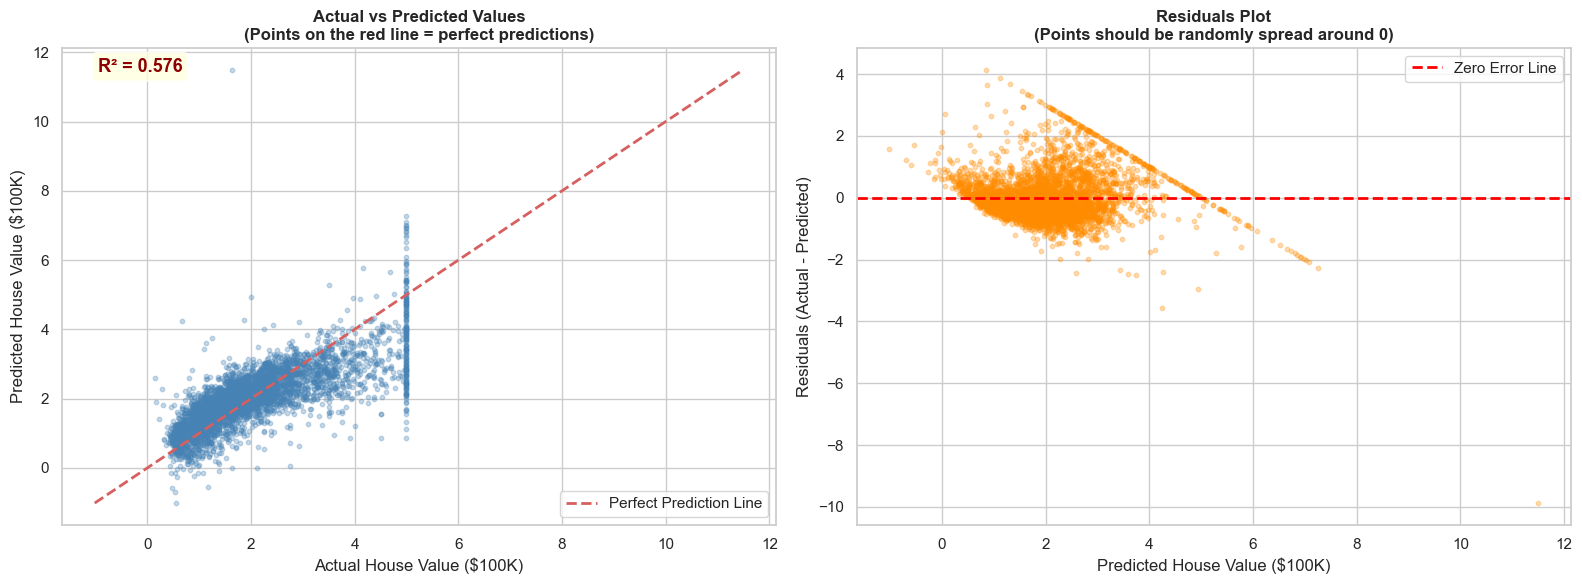

 How to read these charts:
   Left chart  : The closer points are to the red dashed line, the better our predictions
   Right chart : Residuals should be randomly scattered around 0 (no pattern = good model)


In [90]:
# VISUALISE ACTUAL vs PREDICTED VALUES

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Actual vs Predicted Scatter Plot ---
axes[0].scatter(y_test, y_pred_simple, alpha=0.3, color='steelblue', s=10)
min_val = min(y_test.min(), y_pred_simple.min())
max_val = max(y_test.max(), y_pred_simple.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction Line')
axes[0].set_xlabel('Actual House Value ($100K)', fontsize=12)
axes[0].set_ylabel('Predicted House Value ($100K)', fontsize=12)
axes[0].set_title('Actual vs Predicted Values\n(Points on the red line = perfect predictions)',
                   fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=13, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Chart 2: Residuals Plot ---
residuals = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.3, color='darkorange', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
axes[1].set_xlabel('Predicted House Value ($100K)', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residuals Plot\n(Points should be randomly spread around 0)',
                   fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(" How to read these charts:")
print("   Left chart  : The closer points are to the red dashed line, the better our predictions")
print("   Right chart : Residuals should be randomly scattered around 0 (no pattern = good model)")

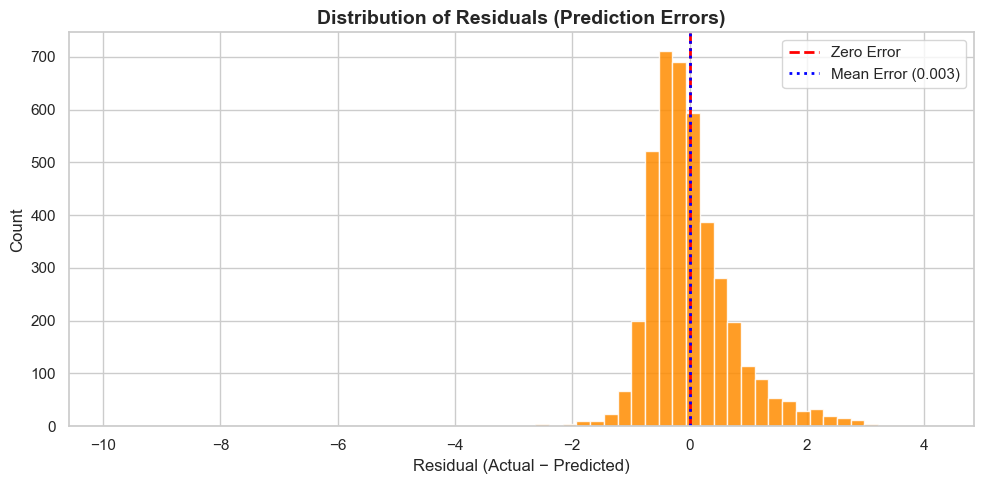

 A good model's residuals should look like a bell curve centred around 0
   Our mean residual: 0.0035 (close to 0 = good, no systematic bias)


In [91]:
# RESIDUALS DISTRIBUTION

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.axvline(residuals.mean(), color='blue', linestyle=':', linewidth=2, label=f'Mean Error ({residuals.mean():.3f})')
plt.title('Distribution of Residuals (Prediction Errors)', fontsize=14, fontweight='bold')
plt.xlabel('Residual (Actual − Predicted)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(" A good model's residuals should look like a bell curve centred around 0")
print(f"   Our mean residual: {residuals.mean():.4f} (close to 0 = good, no systematic bias)")

## Feature Importance

For Linear Regression, we can look at the **model coefficients** to understand which features are most important.

A larger absolute coefficient value = that feature has a stronger influence on the prediction.

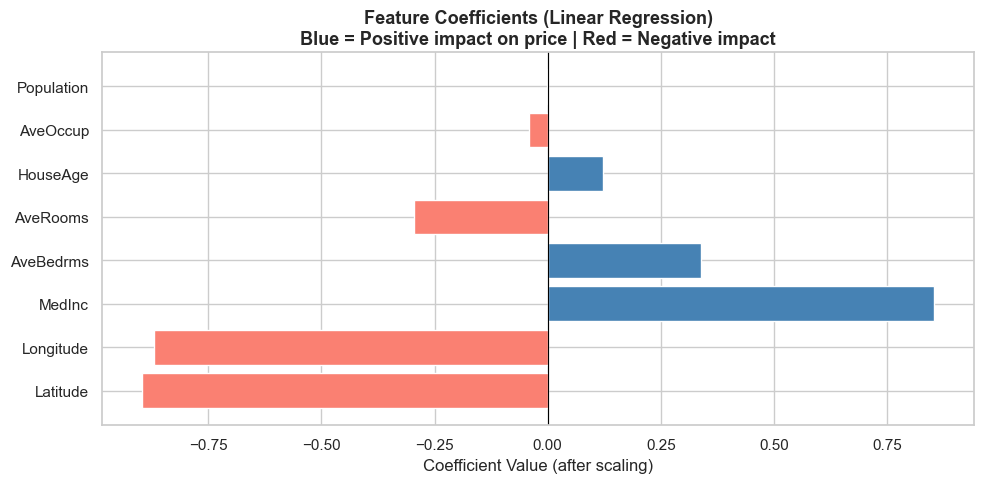


 Feature Coefficients:
   Feature          Coefficient  Effect on Price
   --------------------------------------------------
   Latitude             -0.8969  ↓ Decreases price
   Longitude            -0.8698  ↓ Decreases price
   MedInc                0.8544  ↑ Increases price
   AveBedrms             0.3393  ↑ Increases price
   AveRooms             -0.2944  ↓ Decreases price
   HouseAge              0.1225  ↑ Increases price
   AveOccup             -0.0408  ↓ Decreases price
   Population           -0.0023  ↓ Decreases price

 MedInc (Median Income) has the highest positive coefficient!
   → Higher income neighbourhoods have significantly higher house prices.


In [92]:
# FEATURE IMPORTANCE (Linear Regression Coefficients)

# Extract the model from our simple pipeline
model_coefs = simple_pipeline.named_steps['model'].coef_
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_coefs
}).sort_values('Coefficient', key=abs, ascending=False)

# Plot
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]
plt.figure(figsize=(10, 5))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients (Linear Regression)\nBlue = Positive impact on price | Red = Negative impact',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value (after scaling)')
plt.tight_layout()
plt.show()

print("\n Feature Coefficients:")
print(f"   {'Feature':<15} {'Coefficient':>12}  {'Effect on Price'}")
print("   " + "-"*50)
for _, row in coef_df.iterrows():
    effect = '↑ Increases price' if row['Coefficient'] > 0 else '↓ Decreases price'
    print(f"   {row['Feature']:<15} {row['Coefficient']:>12.4f}  {effect}")

print()
print(" MedInc (Median Income) has the highest positive coefficient!")
print("   → Higher income neighbourhoods have significantly higher house prices.")


##  Summary

In [94]:
print("=" * 65)
print("    SESSION SUMMARY: Introduction to ML & Scikit-learn")
print("=" * 65)
print()
print(" Dataset Used:")
print(f"   California Housing Dataset")
print(f"   {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Target: MedHouseVal (Median House Value)")
print()
print("  Train-Test Split:")
print(f"   Training: {X_train.shape[0]:,} rows (80%)")
print(f"   Testing : {X_test.shape[0]:,} rows (20%)")
print()
print(" Cross-Validation (5-Fold):")
print(f"   Average R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(" Final Model Evaluation (Test Set):")
print(f"   MAE  : {mae:.4f}  (avg error = ${mae*100000:,.0f})")
print(f"   RMSE : {rmse:.4f}  (avg error = ${rmse*100000:,.0f})")
print(f"   R²   : {r2:.4f}  (explains {r2*100:.1f}% of variance)")
print()
print("  Pipeline Steps:")
print("   1. SimpleImputer  → Handle missing values")
print("   2. StandardScaler → Scale features to mean=0, std=1")
print("   3. LinearRegression → Train and predict")
print()
print("=" * 65)
print("   KEY CONCEPTS LEARNED:")
print("=" * 65)
concepts = [
    " Machine Learning workflow (data → train → evaluate → deploy)",
    " Train-test split (never test on training data!)",
    " Feature scaling (StandardScaler, MinMaxScaler, RobustScaler)",
    " Encoding categorical variables (OneHot vs Label)",
    " Handling missing values (drop, mean, median, mode)",
    " K-Fold Cross-Validation (more reliable evaluation)",
    " Stratified K-Fold (for imbalanced classification data)",
    " ML Pipelines (automate and chain all steps together)",
    " ColumnTransformer (different steps for different columns)",
    " Evaluation metrics: MAE, MSE, RMSE, R²",
]
for c in concepts:
    print(f"   {c}")
print("=" * 65)

    SESSION SUMMARY: Introduction to ML & Scikit-learn

 Dataset Used:
   California Housing Dataset
   20,640 rows × 9 columns
   Target: MedHouseVal (Median House Value)

  Train-Test Split:
   Training: 16,512 rows (80%)
   Testing : 4,128 rows (20%)

 Cross-Validation (5-Fold):
   Average R²: 0.6115 ± 0.0065

 Final Model Evaluation (Test Set):
   MAE  : 0.5332  (avg error = $53,320)
   RMSE : 0.7456  (avg error = $74,558)
   R²   : 0.5758  (explains 57.6% of variance)

  Pipeline Steps:
   1. SimpleImputer  → Handle missing values
   2. StandardScaler → Scale features to mean=0, std=1
   3. LinearRegression → Train and predict

   KEY CONCEPTS LEARNED:
    Machine Learning workflow (data → train → evaluate → deploy)
    Train-test split (never test on training data!)
    Feature scaling (StandardScaler, MinMaxScaler, RobustScaler)
    Encoding categorical variables (OneHot vs Label)
    Handling missing values (drop, mean, median, mode)
    K-Fold Cross-Validation (more reliable e